# SVM Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#%pip install scikit-learn 

### Loading the Dataset

In [3]:
df = pd.read_csv('D:\\Poonam Docs\\ML Projects\\SVM Model\\dataset.csv')

In [4]:
# check the missing values in the dataset

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
# divide the dataset into features and target variable
X = df.drop('target', axis=1)
y = df['target']

In [6]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# import the SVM model and train it on the training set
from sklearn.svm import SVC

# create an instance of the SVM model with a linear kernel
svm_model = SVC(kernel='linear')

# train the model on the training set
svm_model.fit(X_train, y_train)

# make predictions on the test set
y_pred = svm_model.predict(X_test)


Accuracy Score: 0.8688524590163934


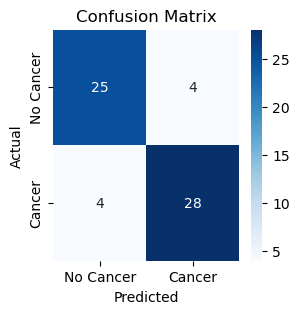

In [8]:
# import the classification report and confusion matrix to evaluate the model   
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

# calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# calculate the accuracy score
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

# plot the confusion matrix using seaborn
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Cancer', 'Cancer'], yticklabels=['No Cancer', 'Cancer'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## With Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# With Hyperparameter Tuning

best_params = {
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1], 
            'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}


# grid search for hyperparameter tuning
grid_search = GridSearchCV(
                        SVC(), 
                        best_params, 
                        cv=5, 
                        scoring='accuracy',
                        verbose=1,
                        n_jobs=-1
                        )

# fit the grid search to the training data
grid_search.fit(X_train, y_train)

# print the best hyperparameters and accuracy score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits